<a href="https://colab.research.google.com/github/mr1xyyy/ML-task/blob/main/ML_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [91]:
import pandas as pd
import numpy as np

In [92]:
df = pd.read_csv('https://gist.githubusercontent.com/mr1xyyy/3a59e7bcc59c10cde284882c911d8a1a/raw/data.csv', index_col=0)
df.head(10)

,district,rooms,size,level,max_levels,price
0,Юнусабадский,2,48.0,3,4,45000.0
1,Яккасарайский,3,75.0,2,9,82000.0
2,Мирабадский,1,35.0,5,5,31000.0
3,Чиланзарский,2,50.0,2,4,43000.0
4,Чиланзарский,4,90.0,4,9,78000.0
5,Мирзо-Улугбекский,3,68.0,1,4,58000.0
6,Учтепинский,1,30.0,4,4,24000.0
7,Яккасарайский,2,54.0,3,5,60000.0
8,Шайхантахурский,3,72.0,6,12,71000.0
9,Сергелийский,2,58.0,4,7,39000.0


In [93]:
housing = df[df.district == 'Яккасарайский']
housing.head()

,district,rooms,size,level,max_levels,price
1,Яккасарайский,3,75.0,2,9,82000.0
7,Яккасарайский,2,54.0,3,5,60000.0


In [94]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(housing, test_size=0.10, random_state=42)

In [95]:
from sklearn import linear_model
MLR_model = linear_model.LinearRegression()

x_train = np.asanyarray(train_set[['rooms','size','level','max_levels']])

y_train = np.asanyarray(train_set[['price']])
MLR_model.fit (x_train, y_train)

print('Coefficients: ', MLR_model.coef_)
print('theta0:', MLR_model.intercept_)

Coefficients:  [[0. 0. 0. 0.]]
theta0: [82000.]


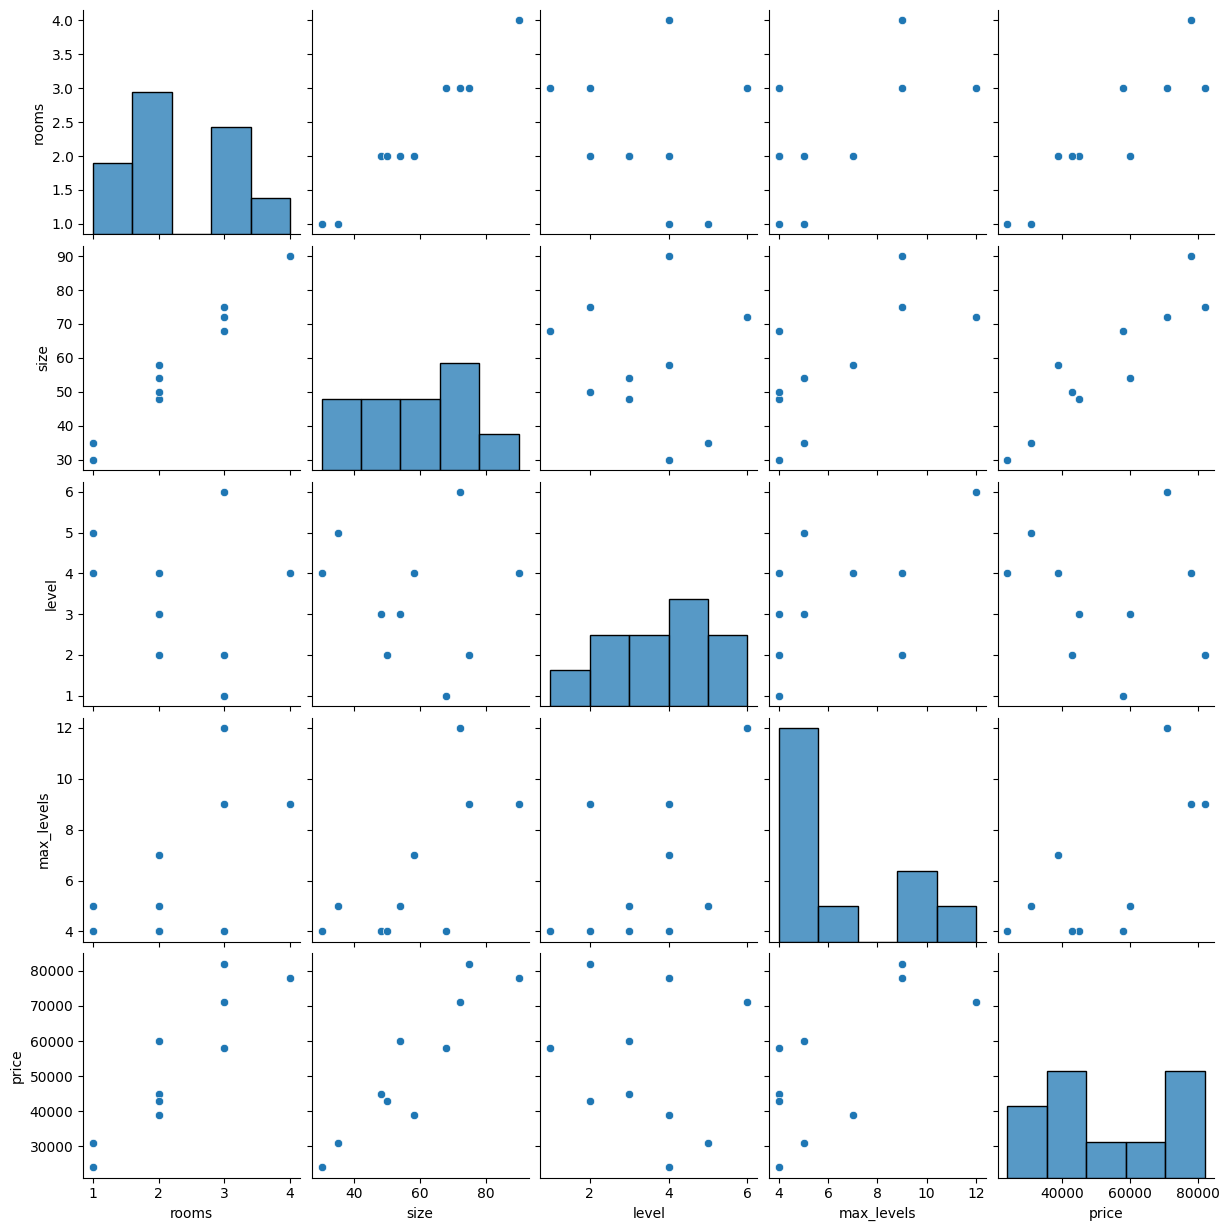

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.pairplot(df[['rooms','size','level','max_levels','price']])
plt.show()

In [97]:
x_test = np.asanyarray(test_set[['rooms','size','level','max_levels']])

y_test = np.asanyarray(test_set[['price']])
y_predict = MLR_model.predict(x_test)

In [98]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

MAE = mean_absolute_error(y_test, y_predict)
RMSE = np.sqrt(mean_squared_error(y_test, y_predict))
print(f"{MAE=}")
print(f"{RMSE=}")

MAE=22000.0
RMSE=np.float64(22000.0)


In [99]:
pred=MLR_model.predict([[2,50,3,3]])
pred

array([[82000.]])

In [100]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(x_train)
x_train_norm = scaler.transform(x_train)
x_test_norm = scaler.transform(x_test)
y_train_norm = scaler.fit_transform(y_train)
y_test_norm = scaler.fit_transform(y_test)

In [101]:
from sklearn import linear_model
MLR_model = linear_model.LinearRegression()

MLR_model.fit (x_train_norm, y_train_norm)

print('Norm_Coefficients: ', MLR_model.coef_)
print('Norm_theta0:', MLR_model.intercept_)

Norm_Coefficients:  [[0. 0. 0. 0.]]
Norm_theta0: [0.]


In [102]:
 y_predict_norm = MLR_model.predict(x_test_norm)

In [103]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

MAE = mean_absolute_error(y_test, y_predict_norm)
RMSE = np.sqrt(mean_squared_error(y_test_norm, y_predict_norm))
print(f"{MAE=}")
print(f"{RMSE=}")

MAE=60000.0
RMSE=np.float64(0.0)
